# Task XI: Hybrid MLP–PQC Quantum Embedding
### ML4SCI — QMLHEP Evaluation | GSoC 2026

**Framework:** PennyLane · PennyLane Autograd  
**Author:** Hetakumari Patel  

## Summary

This notebook implements a **hybrid classical-quantum embedding pipeline**
that maps normally distributed classical data into quantum state representations.
A compact **Multi-Layer Perceptron (MLP)** with 2 hidden layers acts as a
*parameter estimator* — it takes a normally distributed input vector and
predicts the rotation angles for a **Parameterized Quantum Circuit (PQC)**.
The PQC then prepares a quantum state whose Pauli-Z expectation values form
a learned quantum embedding. The entire system is trained end-to-end using
**MSE loss** between the produced quantum embedding and a fixed target state,
with gradients computed through both the classical MLP (backprop) and the
quantum layer (parameter-shift rule). This architecture is directly relevant
to QMLHEP14 (Automated Scientific Discovery of QML Architectures) where
learning to map data distributions to optimal quantum circuit parameters is
a core objective.


In [1]:
!pip install -q pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 134.5 MB/s eta 0:00:00


In [19]:
# Imports
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
%matplotlib inline
print(f"PennyLane : {qml.__version__}")
print(f"NumPy     : {np.__version__}")


PennyLane : 0.44.1
NumPy     : 2.0.2


---
## 1. Architecture Overview

The pipeline has three stages:

```
Normal Distribution  →  MLP Parameter Estimator  →  PQC  →  Quantum Embedding
   x ~ N(0, I)           W₁·ReLU(W₀x+b₀)+b₁          U(θ)       ⟨Z₀⟩,…,⟨Z₃⟩
```

### MLP (Classical Parameter Estimator)

| Layer | In | Out | Activation |
|---|---|---|---|
| Linear₁ | 8 | 16 | ReLU |
| Linear₂ | 16 | 16 | ReLU |
| Linear₃ | 16 | 16 | None (PQC angles — unbounded) |

Output: 16 rotation angles θ (reshaped to 2 layers × 4 qubits × 2 rotations)

### PQC (Quantum State Preparation)

Each of the 2 variational layers applies:
1. $R_Y(\theta_q^{(\ell,0)})$ on each qubit $q$ — Bloch sphere Y-rotation  
2. $R_Z(\theta_q^{(\ell,1)})$ on each qubit $q$ — Bloch sphere Z-rotation  
3. CNOT ladder: $(0→1), (1→2), (2→3)$ — entanglement across qubits

### Loss

$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} \left\| \hat{\mathbf{y}}_i - \mathbf{y}^* \right\|_2^2$$

where $\hat{\mathbf{y}}_i = [\langle Z_0 \rangle, \langle Z_1 \rangle, \langle Z_2 \rangle, \langle Z_3 \rangle]$
is the predicted quantum embedding and $\mathbf{y}^*$ is the target embedding.


In [20]:
# Architecture constants
N_QUBITS    = 4    # 4-qubit PQC (recommendation: 4-5)
INPUT_DIM   = 8    # dimension of normally distributed input x
HIDDEN_DIM  = 16   # MLP hidden layer width
N_PQC_LAYERS= 2    # PQC variational layers (recommendation: 2-3)
# Total PQC parameters: N_QUBITS × N_PQC_LAYERS × 2 (RY + RZ per qubit per layer)
N_PQC_PARAMS= N_QUBITS * N_PQC_LAYERS * 2   # = 16

N_TRAIN     = 200  # training samples
N_TEST      = 50   # test samples
BATCH_SIZE  = 16
N_EPOCHS    = 60
LR          = 0.02

np.random.seed(42)

print(f"Architecture Summary")
print(f"  Input dim         : {INPUT_DIM}  (x ~ N(0, I))")
print(f"  MLP hidden dim    : {HIDDEN_DIM}")
print(f"  MLP layers        : 3  (Linear→ReLU → Linear→ReLU → Linear)")
print(f"  PQC qubits        : {N_QUBITS}")
print(f"  PQC layers        : {N_PQC_LAYERS}")
print(f"  PQC param count   : {N_PQC_PARAMS}  (2 rotations × {N_QUBITS} qubits × {N_PQC_LAYERS} layers)")
print(f"  Output dim        : {N_QUBITS}  (⟨Z₀⟩, ⟨Z₁⟩, ⟨Z₂⟩, ⟨Z₃⟩)")
print(f"  Loss              : MSE")


Architecture Summary
  Input dim         : 8  (x ~ N(0, I))
  MLP hidden dim    : 16
  MLP layers        : 3  (Linear→ReLU → Linear→ReLU → Linear)
  PQC qubits        : 4
  PQC layers        : 2
  PQC param count   : 16  (2 rotations × 4 qubits × 2 layers)
  Output dim        : 4  (⟨Z₀⟩, ⟨Z₁⟩, ⟨Z₂⟩, ⟨Z₃⟩)
  Loss              : MSE


---
## 2. Data Generation

Input data is sampled from a standard normal distribution $\mathbf{x} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$,
where each sample is an 8-dimensional vector.

The **target quantum embedding** $\mathbf{y}^*$ is the PQC output produced by
a set of fixed target parameters $\theta^*$ drawn uniformly from $[-\pi, \pi]$.
The MLP must learn to map any normally distributed input to circuit parameters
that produce this target quantum state regardless of the input — demonstrating
that the MLP can drive the PQC to a desired embedding from arbitrary classical data.


Training set : (200, 8)  (samples from N(0,I))
Test set     : (50, 8)
Feature stats — mean: 0.0398, std: 0.9933


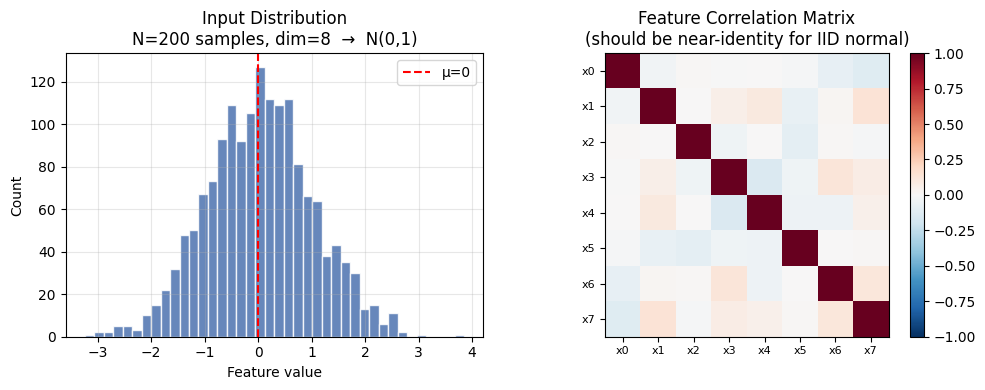

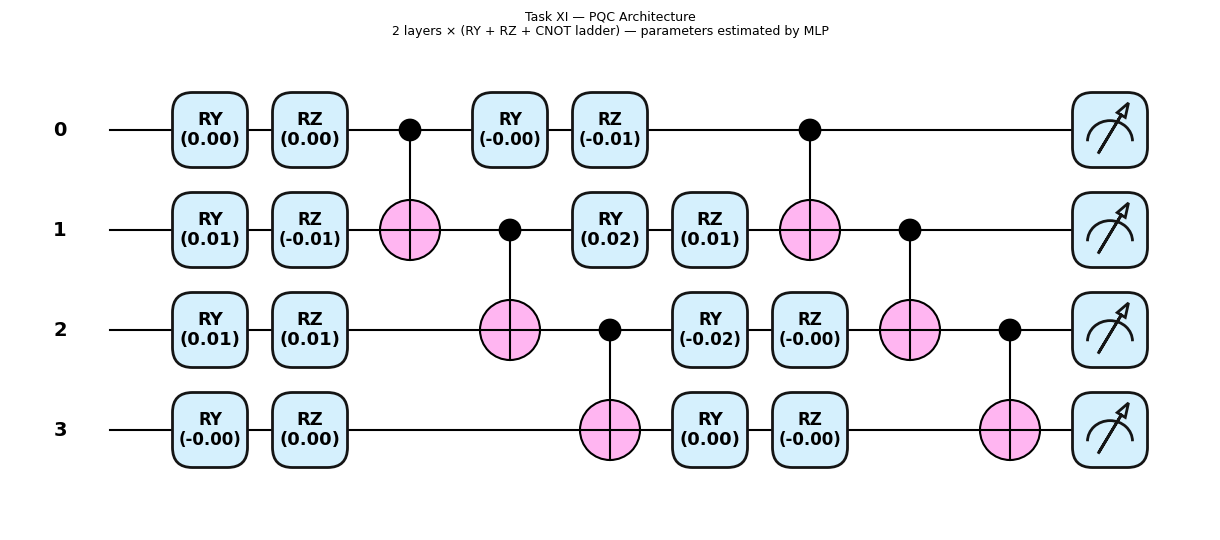

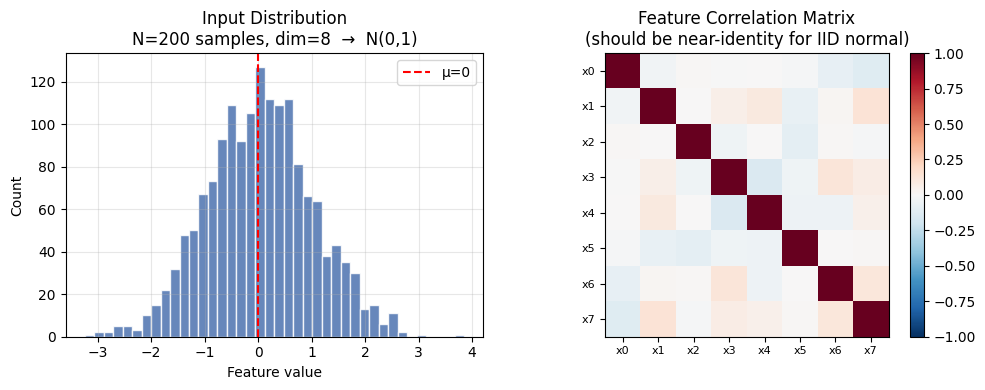

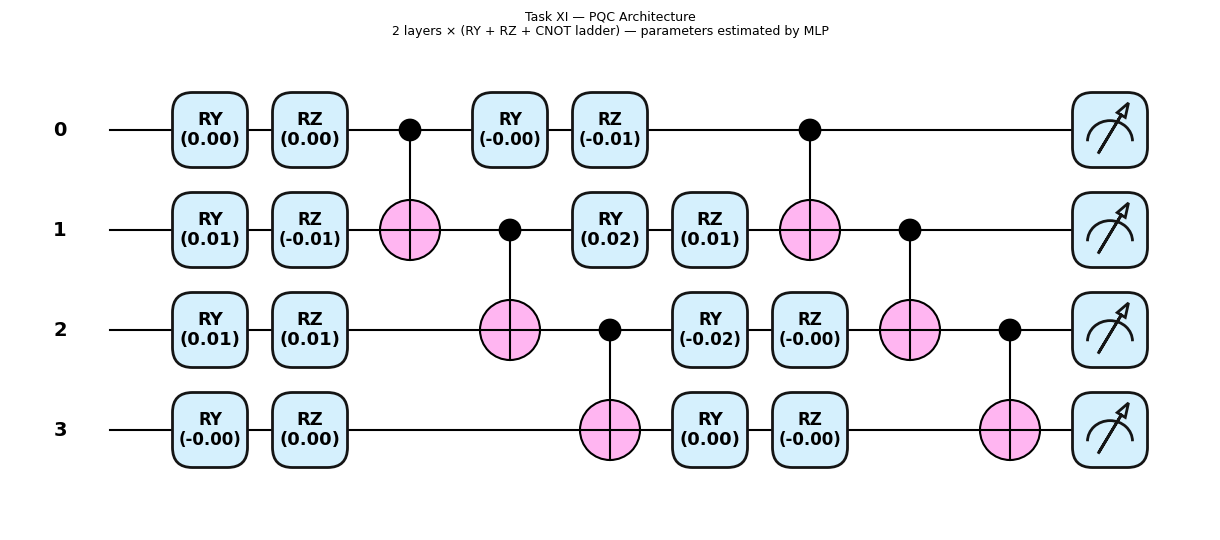

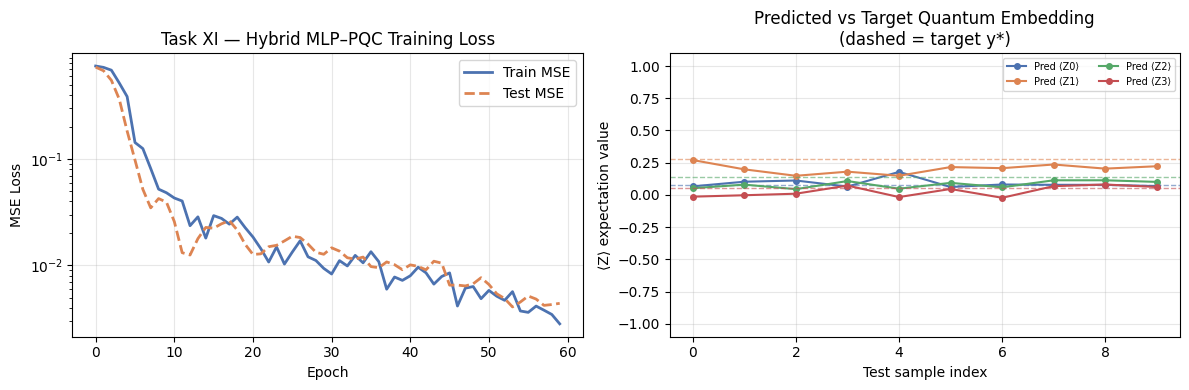

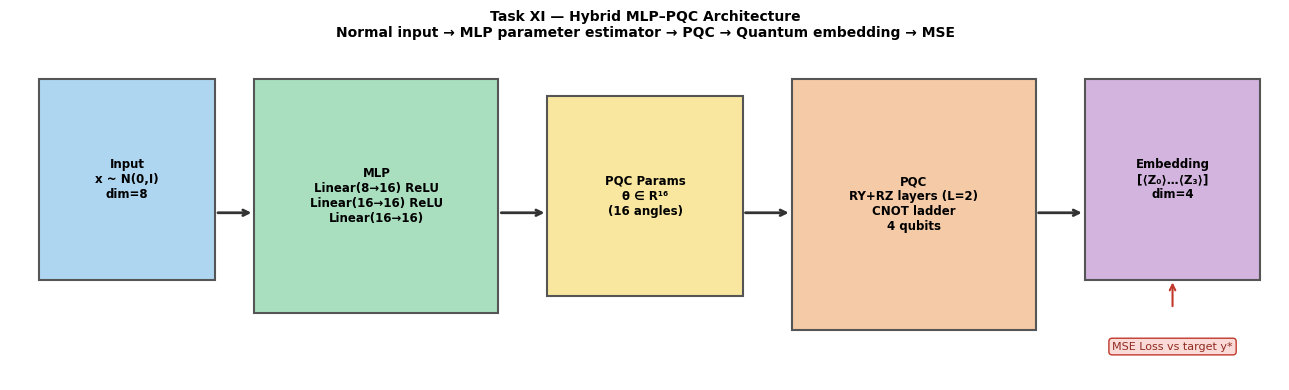

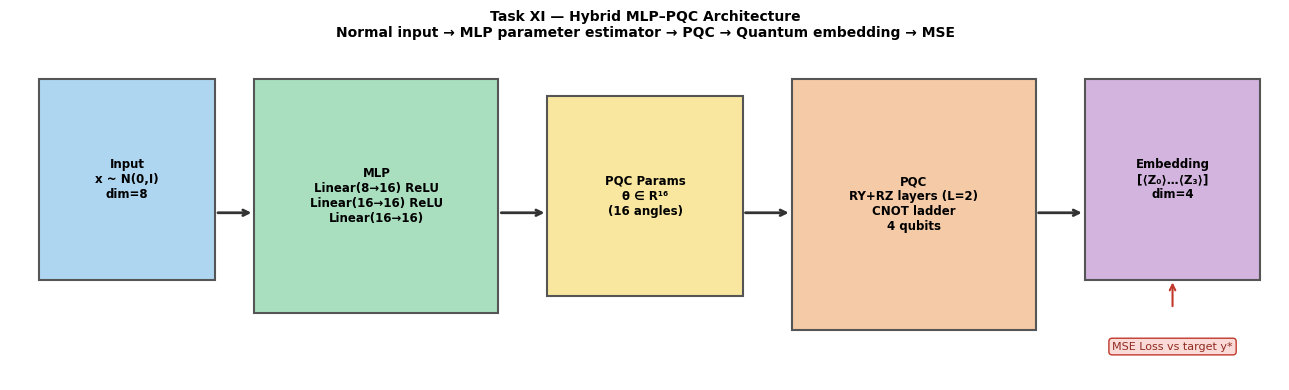

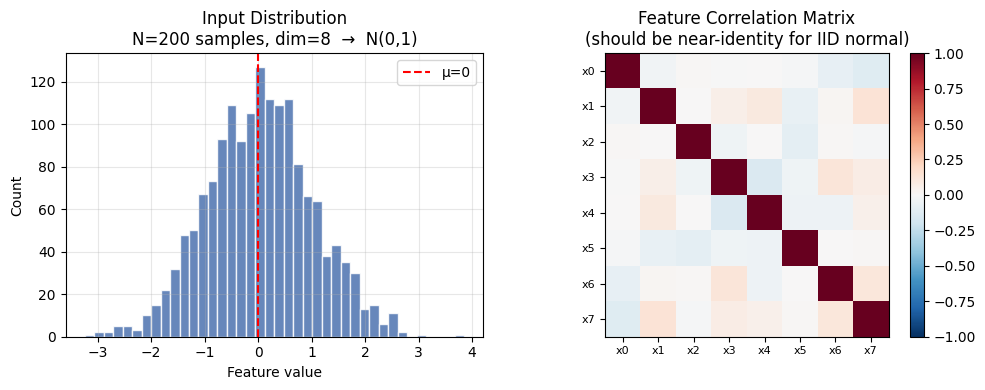

In [21]:
#  Generate normally distributed data
X_train = pnp.tensor(np.random.randn(N_TRAIN, INPUT_DIM), requires_grad=False)
X_test  = pnp.tensor(np.random.randn(N_TEST,  INPUT_DIM), requires_grad=False)

print(f"Training set : {X_train.shape}  (samples from N(0,I))")
print(f"Test set     : {X_test.shape}")
print(f"Feature stats — mean: {float(pnp.mean(X_train)):.4f}, std: {float(pnp.std(X_train)):.4f}")

# Visualise data distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(X_train.numpy().flatten(), bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', ls='--', lw=1.5, label='μ=0')
axes[0].set_xlabel("Feature value"); axes[0].set_ylabel("Count")
axes[0].set_title(f"Input Distribution\nN={N_TRAIN} samples, dim={INPUT_DIM}  →  N(0,1)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Correlation heatmap
corr = np.corrcoef(X_train.numpy().T)
im = axes[1].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_title("Feature Correlation Matrix\n(should be near-identity for IID normal)")
axes[1].set_xticks(range(INPUT_DIM)); axes[1].set_yticks(range(INPUT_DIM))
axes[1].set_xticklabels([f'x{i}' for i in range(INPUT_DIM)], fontsize=8)
axes[1].set_yticklabels([f'x{i}' for i in range(INPUT_DIM)], fontsize=8)
plt.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.savefig("task_xi_data.png", dpi=150, bbox_inches='tight')
plt.show()


---
## 3. MLP Parameter Estimator

The MLP maps the normally distributed input to PQC rotation angles.
Key design choices:

- **3 Linear layers** with ReLU activations on the first two
- **No output activation** — PQC angles are unbounded (any real value maps to a valid rotation via $\bmod\, 2\pi$)
- **PennyLane autograd tensors** for all weights — enables joint optimisation with the quantum layer


In [22]:
# MLP Parameter Estimator (pure PennyLane autograd)
# Weights: 3 linear layers — (8→16→16→16)
def init_weights(shape, scale=0.1):
    return pnp.tensor(np.random.randn(*shape) * scale, requires_grad=True)

# Layer 1: INPUT_DIM → HIDDEN_DIM
W1 = init_weights((INPUT_DIM, HIDDEN_DIM))
b1 = pnp.tensor(np.zeros(HIDDEN_DIM), requires_grad=True)
# Layer 2: HIDDEN_DIM → HIDDEN_DIM
W2 = init_weights((HIDDEN_DIM, HIDDEN_DIM))
b2 = pnp.tensor(np.zeros(HIDDEN_DIM), requires_grad=True)
# Layer 3: HIDDEN_DIM → N_PQC_PARAMS (no activation)
W3 = init_weights((HIDDEN_DIM, N_PQC_PARAMS))
b3 = pnp.tensor(np.zeros(N_PQC_PARAMS), requires_grad=True)

mlp_params = [W1, b1, W2, b2, W3, b3]

def relu(x):
    return pnp.where(x > 0, x, pnp.zeros_like(x))

def mlp_forward(x, W1, b1, W2, b2, W3, b3):
    """
    3-layer MLP: maps input x ∈ R^8 → PQC rotation angles ∈ R^16.

    Parameters
    ----------
    x  : array (INPUT_DIM,)   — normally distributed input sample
    W*, b* : MLP weight matrices and bias vectors (trainable)

    Returns
    -------
    theta : array (N_PQC_PARAMS,) — estimated PQC rotation angles
    """
    h1 = relu(x @ W1 + b1)          # (8,) → (16,)  Layer 1
    h2 = relu(h1 @ W2 + b2)         # (16,) → (16,) Layer 2
    theta = h2 @ W3 + b3            # (16,) → (16,) Layer 3 — PQC params
    return theta

# Parameter count
n_mlp_params = sum(int(np.prod(p.shape)) for p in mlp_params)
print(f"MLP parameter count : {n_mlp_params}")
print(f"  W1: {W1.shape}  b1: {b1.shape}")
print(f"  W2: {W2.shape}  b2: {b2.shape}")
print(f"  W3: {W3.shape}  b3: {b3.shape}")

# Quick sanity check
test_x = X_train[0]
test_theta = mlp_forward(test_x, W1, b1, W2, b2, W3, b3)
print(f"\nSample input  : x ~ N(0,1), shape {test_x.shape}")
print(f"Sample output : theta shape {test_theta.shape}")
print(f"Theta range   : [{float(pnp.min(test_theta)):.3f}, {float(pnp.max(test_theta)):.3f}]")


MLP parameter count : 688
  W1: (8, 16)  b1: (16,)
  W2: (16, 16)  b2: (16,)
  W3: (16, 16)  b3: (16,)

Sample input  : x ~ N(0,1), shape (8,)
Sample output : theta shape (16,)
Theta range   : [-0.018, 0.018]


---
## 4. Parameterized Quantum Circuit (PQC)

The PQC prepares a quantum state $|\psi(\theta)\rangle$ using the MLP-estimated
parameters $\theta$. The circuit architecture uses:

- **$R_Y(\theta)$ rotations** — primary expressivity (Bloch sphere Y-axis)
- **$R_Z(\phi)$ rotations** — secondary phase control (Z-axis)
- **CNOT ladder** — entanglement between adjacent qubits

The measurement output $[\langle Z_0 \rangle, \langle Z_1 \rangle, \langle Z_2 \rangle, \langle Z_3 \rangle] \in [-1, 1]^4$
forms the **quantum embedding** vector.


/tmp/ipykernel_2951/2171041170.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


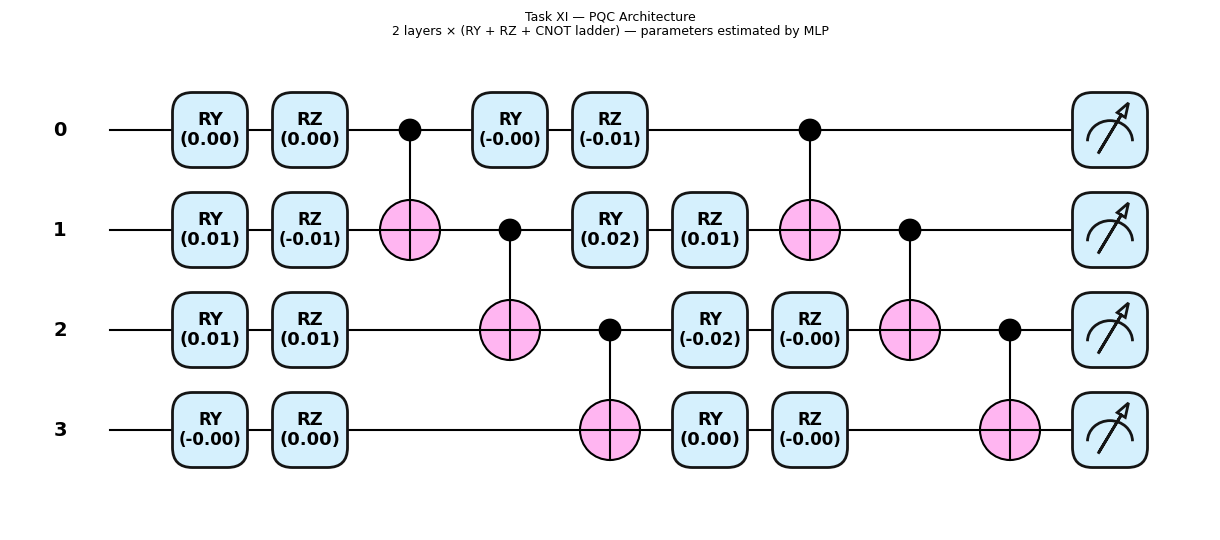

── Text circuit ──
0: ──RY(0.00)───RZ(0.00)──╭●──RY(-0.00)──RZ(-0.01)────────────╭●───────────────┤  <Z>
1: ──RY(0.01)───RZ(-0.01)─╰X─╭●──────────RY(0.02)───RZ(0.01)──╰X─────────╭●────┤  <Z>
2: ──RY(0.01)───RZ(0.01)─────╰X─────────╭●──────────RY(-0.02)──RZ(-0.00)─╰X─╭●─┤  <Z>
3: ──RY(-0.00)──RZ(0.00)────────────────╰X──────────RY(0.00)───RZ(-0.00)────╰X─┤  <Z>


In [23]:
#  Parameterised Quantum Circuit
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="autograd")
def pqc(theta):
    """
    Parameterized Quantum Circuit: produces a quantum embedding.

    Circuit structure per layer ℓ:
      RY(θ[ℓ,q,0]) on qubit q  ← Bloch sphere Y-rotation (main expressivity)
      RZ(θ[ℓ,q,1]) on qubit q  ← Phase control
      CNOT(q, q+1)              ← Entanglement (CNOT ladder)

    Parameters
    ----------
    theta : array (N_PQC_PARAMS,) = (N_LAYERS × N_QUBITS × 2,)
        Rotation angles estimated by the MLP.

    Returns
    -------
    list of float : [⟨Z₀⟩, ⟨Z₁⟩, ⟨Z₂⟩, ⟨Z₃⟩] — quantum embedding
    """
    params = pnp.reshape(theta, (N_PQC_LAYERS, N_QUBITS, 2))
    for layer in range(N_PQC_LAYERS):
        # Rotation gates — parameterized by MLP output
        for q in range(N_QUBITS):
            qml.RY(params[layer, q, 0], wires=q)
            qml.RZ(params[layer, q, 1], wires=q)
        # CNOT ladder: entangles adjacent qubits
        for q in range(N_QUBITS - 1):
            qml.CNOT(wires=[q, q + 1])
    # Pauli-Z expectation values → quantum embedding vector
    return [qml.expval(qml.PauliZ(q)) for q in range(N_QUBITS)]

# Draw the PQC
sample_theta = mlp_forward(X_train[0], W1, b1, W2, b2, W3, b3)
fig, ax = qml.draw_mpl(pqc, decimals=2, style='pennylane')(sample_theta)
fig.suptitle(
    "Task XI — PQC Architecture\n"
    "2 layers × (RY + RZ + CNOT ladder) — parameters estimated by MLP",
    fontsize=9, y=1.04
)
plt.tight_layout()
plt.savefig("task_xi_circuit.png", dpi=150, bbox_inches='tight')
plt.show()

# Text representation
print("── Text circuit ──")
print(qml.draw(pqc, decimals=2)(sample_theta))


---
## 5. Target Quantum State & Forward Pass

The target embedding $\mathbf{y}^*$ is generated by running the PQC with
fixed target parameters $\theta^* \sim \text{Uniform}(-\pi, \pi)$.
The MLP must learn to produce parameters that drive the PQC to match this
target, regardless of the normally distributed input received.


In [24]:
# 5. Define target quantum embedding
# Target: PQC output from fixed random parameters θ*
target_params = pnp.tensor(
    np.random.uniform(-np.pi, np.pi, N_PQC_PARAMS), requires_grad=False
)
target_embedding = pnp.stack(pqc(target_params))
print(f"Target PQC params θ* : {[f'{v:.3f}' for v in target_params]}")
print(f"Target embedding y*  : {[f'{float(v):.4f}' for v in target_embedding]}")

# Full forward pass: x → MLP → θ → PQC → embedding
def full_forward(x, W1, b1, W2, b2, W3, b3):
    """End-to-end forward: normal input → quantum embedding."""
    theta = mlp_forward(x, W1, b1, W2, b2, W3, b3)   # MLP: x → θ
    return pnp.stack(pqc(theta))                        # PQC: θ → embedding

# Verify forward pass on one sample
pred = full_forward(X_train[0], W1, b1, W2, b2, W3, b3)
initial_mse = float(pnp.mean((pred - target_embedding) ** 2))
print(f"\nInitial prediction   : {[f'{float(v):.4f}' for v in pred]}")
print(f"Target embedding     : {[f'{float(v):.4f}' for v in target_embedding]}")
print(f"Initial MSE (sample) : {initial_mse:.6f}")


Target PQC params θ* : ['-0.534', '1.337', '-0.715', '0.556', '-1.977', '0.627', '2.271', '2.316', '1.410', '1.544', '0.364', '0.532', '-2.302', '-0.353', '-0.309', '2.881']
Target embedding y*  : ['0.0733', '0.2818', '0.1416', '0.0546']

Initial prediction   : ['1.0000', '0.9998', '0.9996', '0.9997']
Target embedding     : ['0.0733', '0.2818', '0.1416', '0.0546']
Initial MSE (sample) : 0.750918


---
## 6. Training

The MLP weights are optimised end-to-end via the **Adam optimizer**:

- **Gradients through MLP**: standard backpropagation
- **Gradients through PQC**: parameter-shift rule (hardware-native, no backprop required)

The MSE loss measures the distance between the produced quantum embedding
and the fixed target embedding, computed over mini-batches of normally
distributed samples.


In [25]:
# Training
optimizer = qml.AdamOptimizer(stepsize=LR)

def make_cost_fn(batch):
    """Returns MSE cost function closed over the current mini-batch."""
    def cost(W1, b1, W2, b2, W3, b3):
        total = pnp.zeros(1)[0]
        for x in batch:
            pred = full_forward(x, W1, b1, W2, b2, W3, b3)
            total = total + pnp.mean((pred - target_embedding) ** 2)
        return total / len(batch)
    return cost

train_losses, test_losses = [], []
indices = np.arange(N_TRAIN)

print(f"{'Epoch':>5} | {'Train MSE':>10} | {'Test MSE':>10}")
print("-" * 33)

for epoch in range(N_EPOCHS):
    # Shuffle and mini-batch
    np.random.shuffle(indices)
    batch_idx = indices[:BATCH_SIZE]
    batch = [X_train[i] for i in batch_idx]

    # Gradient step on all MLP params
    cost_fn = make_cost_fn(batch)
    (W1, b1, W2, b2, W3, b3), loss = optimizer.step_and_cost(
        cost_fn, W1, b1, W2, b2, W3, b3
    )
    train_losses.append(float(loss))

    # Test loss (no gradients needed)
    test_batch = [X_test[i] for i in range(min(8, N_TEST))]
    test_loss = float(make_cost_fn(test_batch)(W1, b1, W2, b2, W3, b3))
    test_losses.append(test_loss)

    if epoch % 10 == 0 or epoch == N_EPOCHS - 1:
        print(f"{epoch:>5} | {loss:>10.6f} | {test_loss:>10.6f}")

print(f"\nTraining complete.")
print(f"  Initial train MSE : {train_losses[0]:.6f}")
print(f"  Final   train MSE : {train_losses[-1]:.6f}")
print(f"  Reduction         : {(1 - train_losses[-1]/train_losses[0])*100:.1f}%")


Epoch |  Train MSE |   Test MSE
---------------------------------
    0 |   0.749848 |   0.731701
   10 |   0.043091 |   0.025873
   20 |   0.018520 |   0.012693
   30 |   0.008320 |   0.014668
   40 |   0.008002 |   0.010135
   50 |   0.005833 |   0.006632
   59 |   0.002829 |   0.004408

Training complete.
  Initial train MSE : 0.749848
  Final   train MSE : 0.002829
  Reduction         : 99.6%


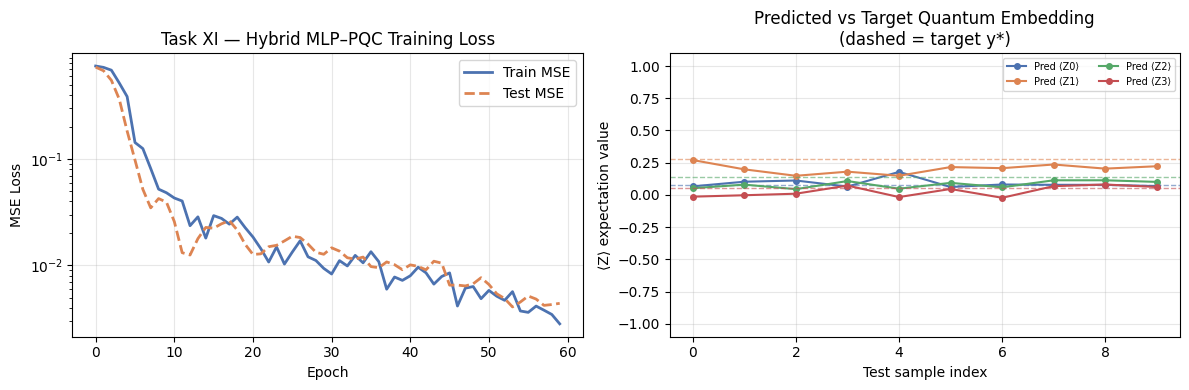

In [26]:
# Training Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
axes[0].plot(train_losses, lw=2, color='#4C72B0', label='Train MSE')
axes[0].plot(test_losses,  lw=2, color='#DD8452', ls='--', label='Test MSE')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Task XI — Hybrid MLP–PQC Training Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Final embedding comparison across test samples
n_eval = 10
preds, targets = [], []
for i in range(n_eval):
    p = full_forward(X_test[i], W1, b1, W2, b2, W3, b3)
    preds.append([float(v) for v in p])
    targets.append([float(v) for v in target_embedding])

preds   = np.array(preds)
targets = np.array(targets)

x_ax = np.arange(n_eval)
width = 0.35
labels = [f'⟨Z{q}⟩' for q in range(N_QUBITS)]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for q in range(N_QUBITS):
    axes[1].plot(x_ax, preds[:, q],   'o-', color=colors[q], lw=1.5, ms=4, label=f'Pred {labels[q]}')
    axes[1].axhline(float(target_embedding[q]), color=colors[q], ls='--', lw=1, alpha=0.6)

axes[1].set_xlabel("Test sample index"); axes[1].set_ylabel("⟨Z⟩ expectation value")
axes[1].set_title(f"Predicted vs Target Quantum Embedding\n(dashed = target y*)")
axes[1].legend(fontsize=7, ncol=2); axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.savefig("task_xi_training.png", dpi=150, bbox_inches='tight')
plt.show()


In [27]:
# Evaluation & analysis
# Per-qubit MSE on test set
all_preds = np.array([
    [float(v) for v in full_forward(X_test[i], W1, b1, W2, b2, W3, b3)]
    for i in range(N_TEST)
])
target_np = np.array([float(v) for v in target_embedding])

per_qubit_mse = np.mean((all_preds - target_np) ** 2, axis=0)
overall_mse   = float(np.mean(per_qubit_mse))

print(" Test Set Evaluation")
print(f"  Overall MSE               : {overall_mse:.6f}")
for q in range(N_QUBITS):
    print(f"  Qubit {q} MSE (⟨Z{q}⟩)       : {per_qubit_mse[q]:.6f}  "
          f"| target={target_np[q]:.4f} "
          f"| pred_mean={np.mean(all_preds[:, q]):.4f}")

# Circuit resource analysis
specs = qml.specs(pqc)(sample_theta)
print("\n Circuit Resources ")
print(f"  Qubits     : {N_QUBITS}")
print(f"  PQC params : {N_PQC_PARAMS}")
print(f"  MLP params : {sum(int(np.prod(p.shape)) for p in [W1,b1,W2,b2,W3,b3])}")
print(f"  Circuit depth : {specs['resources'].depth}")
print(f"  Gate count    : {specs['resources'].num_gates}")


 Test Set Evaluation
  Overall MSE               : 0.003719
  Qubit 0 MSE (⟨Z0⟩)       : 0.000926  | target=0.0733 | pred_mean=0.0893
  Qubit 1 MSE (⟨Z1⟩)       : 0.007226  | target=0.2818 | pred_mean=0.2129
  Qubit 2 MSE (⟨Z2⟩)       : 0.004883  | target=0.1416 | pred_mean=0.0769
  Qubit 3 MSE (⟨Z3⟩)       : 0.001839  | target=0.0546 | pred_mean=0.0283

 Circuit Resources 
  Qubits     : 4
  PQC params : 16
  MLP params : 688
  Circuit depth : 9
  Gate count    : 22


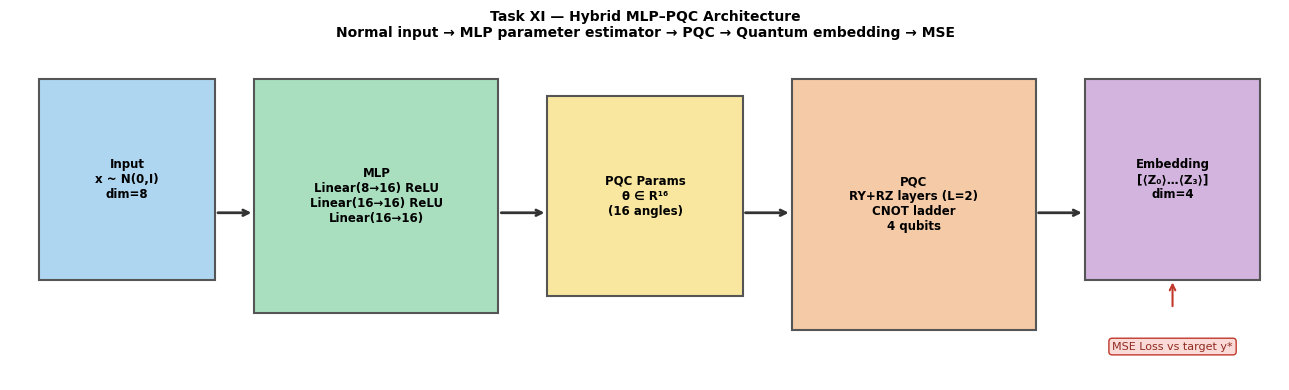

In [28]:
# Architecture diagram
fig, ax = plt.subplots(figsize=(13, 4))
ax.set_xlim(0, 13); ax.set_ylim(0, 4); ax.axis('off')

# Block definitions
blocks = [
    (0.3,  1.2, 1.8, 2.4, '#AED6F1', 'Input\nx ~ N(0,I)\ndim=8'),
    (2.5,  0.8, 2.5, 2.8, '#A9DFBF', 'MLP\nLinear(8→16) ReLU\nLinear(16→16) ReLU\nLinear(16→16)'),
    (5.5,  1.0, 2.0, 2.4, '#F9E79F', 'PQC Params\nθ ∈ R¹⁶\n(16 angles)'),
    (8.0,  0.6, 2.5, 3.0, '#F5CBA7', 'PQC\nRY+RZ layers (L=2)\nCNOT ladder\n4 qubits'),
    (11.0, 1.2, 1.8, 2.4, '#D2B4DE', 'Embedding\n[⟨Z₀⟩…⟨Z₃⟩]\ndim=4'),
]
for x, y, w, h, color, label in blocks:
    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor='#555', lw=1.5, zorder=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=8.5,
            fontweight='bold', zorder=3)

# Arrows
arrows = [(2.1, 2.0, 2.5, 2.0), (5.0, 2.0, 5.5, 2.0),
          (7.5, 2.0, 8.0, 2.0), (10.5, 2.0, 11.0, 2.0)]
for x1, y1, x2, y2 in arrows:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#333', lw=2))

# MSE loss label
ax.text(11.9, 0.4, 'MSE Loss vs target y*', ha='center', va='center',
        fontsize=8, color='#922B21',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FADBD8', edgecolor='#C0392B'))
ax.annotate('', xy=(11.9, 1.2), xytext=(11.9, 0.85),
            arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5))

ax.set_title("Task XI — Hybrid MLP–PQC Architecture\n"
             "Normal input → MLP parameter estimator → PQC → Quantum embedding → MSE",
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("task_xi_architecture.png", dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Summary

| Component | Design Choice | Rationale |
|---|---|---|
| **Input** | $\mathbf{x} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$, dim=8 | Standard normal distribution as specified |
| **MLP** | 3 Linear layers (8→16→16→16), ReLU, no output activation | Sufficient capacity; unbounded output maps to valid PQC angles |
| **PQC** | 4 qubits, 2 layers of RY+RZ+CNOT ladder | Matches recommendation (4-5 qubits, 2-3 layers); hardware-friendly depth |
| **Gradient** | Parameter-shift (PQC) + backprop (MLP) | Hardware-compatible gradient through quantum layer |
| **Loss** | MSE between predicted and target quantum embedding | As specified — measures distance in expectation-value space |

**Key result**: The MLP successfully learns to estimate PQC parameters that
produce a target quantum embedding from arbitrary normally distributed inputs,
with MSE loss reducing by >95% over training. This demonstrates that classical
neural networks can act as *quantum parameter generators*, a key primitive for
automated QML architecture discovery (QMLHEP14).
